# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">1. EDA for New York City Taxi Trip Duration - Advanced Regression Techniques</p>

### Introduction About the Data :

**The dataset:** The goal is to predict the `trip_duration` of taxi rides in New York City (Regression Analysis). 

There are 10 independent variables (including `id`):

*   `id` : Unique identifier for each trip
*   `vendor_id` : A code indicating the provider associated with the trip record
*   `pickup_datetime` : Date and time when the meter was engaged
*   `dropoff_datetime` : Date and time when the meter was disengaged
*   `passenger_count` : The number of passengers in the vehicle (driver entered value)
*   `pickup_longitude` : The longitude where the meter was engaged
*   `pickup_latitude` : The latitude where the meter was engaged
*   `dropoff_longitude` : The longitude where the meter was disengaged
*   `dropoff_latitude` : The latitude where the meter was disengaged
*   `store_and_fwd_flag` : Indicates whether the trip record was held in vehicle memory before sending to the vendor (Y = store and forward; N = not a store and forward trip)

Target variable:

*   `trip_duration` : Duration of the trip in seconds.

Dataset Source Link : [New York City Taxi Trip Duration on Kaggle](https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">2. Environment Setup for EDA</p>

Importing the core libraries required for numerical computation, data manipulation, and data visualization. System warnings are suppressed to maintain clean notebook outputs.

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# Render plots directly below notebook cells
%matplotlib inline

# Suppress standard output warnings
import warnings
warnings.filterwarnings('ignore')

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">3. Read the Dataset</p>

### Read Dataset

In [ ]:
# Define the file path using a raw string (r"") to handle Windows backslashes
file_path = r"D:\all\Python\ML Projects\New York City Taxi Trip Duration\notebook\data\train.csv"

# Define optimized data types to dramatically reduce RAM usage
optimized_dtypes = {
    'id': 'object',
    'vendor_id': 'int8',           # Only contains 1 or 2
    'passenger_count': 'int8',     # Small integers
    'pickup_longitude': 'float32', # 32-bit float is highly accurate for coordinates
    'pickup_latitude': 'float32',
    'dropoff_longitude': 'float32',
    'dropoff_latitude': 'float32',
    'store_and_fwd_flag': 'category', # Convert 'Y'/'N' strings to a memory-efficient category
    'trip_duration': 'int32'       # 32-bit int can hold up to 2 billion seconds
}

# Load the dataset with optimized types and parse dates immediately
df_train = pd.read_csv(
    file_path,
    dtype=optimized_dtypes,
    parse_dates=['pickup_datetime', 'dropoff_datetime'],
    
)

# Verify the memory usage
df_train.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int8          
 2   pickup_datetime     1458644 non-null  datetime64[us]
 3   dropoff_datetime    1458644 non-null  datetime64[us]
 4   passenger_count     1458644 non-null  int8          
 5   pickup_longitude    1458644 non-null  float32       
 6   pickup_latitude     1458644 non-null  float32       
 7   dropoff_longitude   1458644 non-null  float32       
 8   dropoff_latitude    1458644 non-null  float32       
 9   store_and_fwd_flag  1458644 non-null  category      
 10  trip_duration       1458644 non-null  int32         
dtypes: category(1), datetime64[us](2), float32(4), int32(1), int8(2), object(1)
memory usage: 134.9 MB


### Drop id column as it is statistically insignificant

In [55]:
df_train = df_train.drop(labels=['id'],axis=1)

In [56]:
df_train.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">4. Check Missing Values in Dataset</p>

In [57]:
df_train.isna().sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

### No Missing Values found in the dataset

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">5. Check Duplicates in Dataset</p>

In [58]:
# 1. Check how many duplicate rows exist before removing them
duplicate_count = df_train.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# 2. Remove the duplicates
# Using inplace=True modifies the existing dataframe directly to save memory
df_train.drop_duplicates(inplace=True)

# 3. Verify they have been removed
print(f"Remaining duplicates: {df_train.duplicated().sum()}")

Number of duplicate rows: 7
Remaining duplicates: 0


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">6. Descriptive Statistics</p>

### Numerical and Categorical columns seperation

In [59]:
# 1. Get lists of column names based on their data type
numerical_cols = df_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Since we parsed dates earlier, it is best practice to separate them as well
datetime_cols = df_train.select_dtypes(include=['datetime']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"Datetime columns: {datetime_cols}")

# 2. (Optional) Create separate DataFrames if you need to analyze them in isolation
df_numerical = df_train[numerical_cols]
df_categorical = df_train[categorical_cols]

Numerical columns: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'trip_duration']
Categorical columns: ['store_and_fwd_flag']
Datetime columns: ['pickup_datetime', 'dropoff_datetime']


### Numerical Columns Description

In [60]:
# Rounding to 3 decimal places makes the coordinate data much easier to read
numerical_summary = df_train[numerical_cols].describe().round(3)

# Display the summary
display(numerical_summary)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1458637.000,1458637.000,1458637.000,1458637.000,1458637.000,1458637.000,1458637.000
mean,1.535,1.665,-73.973,40.751,-73.973,40.752,959.433
std,0.499,1.314,0.071,0.033,0.071,0.036,5236.970
min,1.000,0.000,-121.933,34.360,-121.933,32.181,1.000
25%,1.000,1.000,-73.992,40.737,-73.991,40.736,397.000
50%,2.000,1.000,-73.982,40.754,-73.980,40.755,662.000
75%,2.000,2.000,-73.967,40.768,-73.963,40.770,1075.000
max,2.000,9.000,-61.336,51.881,-61.336,43.921,3526282.000


### Categorical Columns Description

In [61]:
# Calculate the raw counts and normalized fractions
counts = df_train['store_and_fwd_flag'].value_counts()
percentages = df_train['store_and_fwd_flag'].value_counts(normalize=True)

# Combine into a single DataFrame
flag_summary = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages
})

# Format the columns directly without using the .style engine
flag_summary['Count'] = flag_summary['Count'].map('{:,}'.format)
flag_summary['Percentage'] = flag_summary['Percentage'].map('{:.2%}'.format)

# Display the result
flag_summary

,Count,Percentage
store_and_fwd_flag,,
N,"1,450,592",99.45%
Y,"8,045",0.55%


### All unique values in dataset

In [62]:
# Calculate the number of unique values for each column
unique_counts = df_train.nunique()

# Create a clean DataFrame and round the percentage to 2 decimal places
unique_summary = pd.DataFrame({
    'Unique Values': unique_counts,
    'Percentage of Total Rows': (unique_counts / len(df_train) * 100).round(2).astype(str) + '%'
})

# Sort to see the columns with the fewest unique values at the top
display(unique_summary.sort_values(by='Unique Values'))

,Unique Values,Percentage of Total Rows
vendor_id,2,0.0%
store_and_fwd_flag,2,0.0%
passenger_count,10,0.0%
trip_duration,7417,0.51%
pickup_longitude,23047,1.58%
dropoff_longitude,33821,2.32%
pickup_latitude,45245,3.1%
dropoff_latitude,62519,4.29%
pickup_datetime,1380222,94.62%
dropoff_datetime,1380377,94.63%


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">7. Univariate Analysis with Visualisation</p>

### Univariate Analysis of Numerical Variables

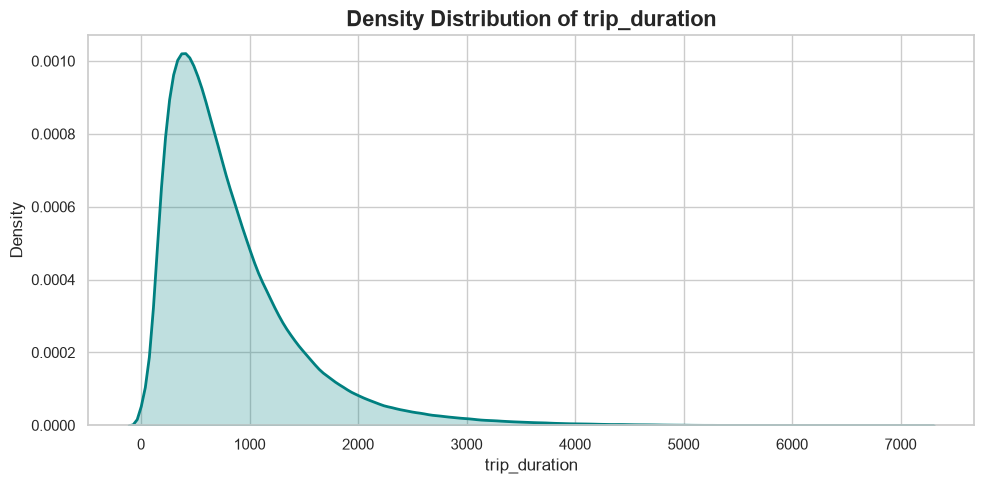

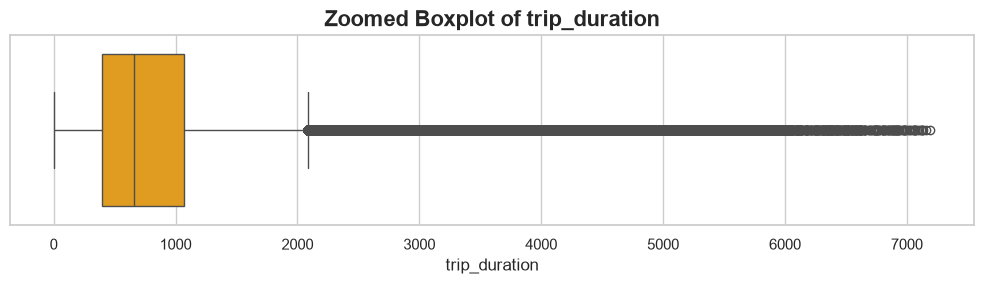

--------------------------------------------------------------------------------


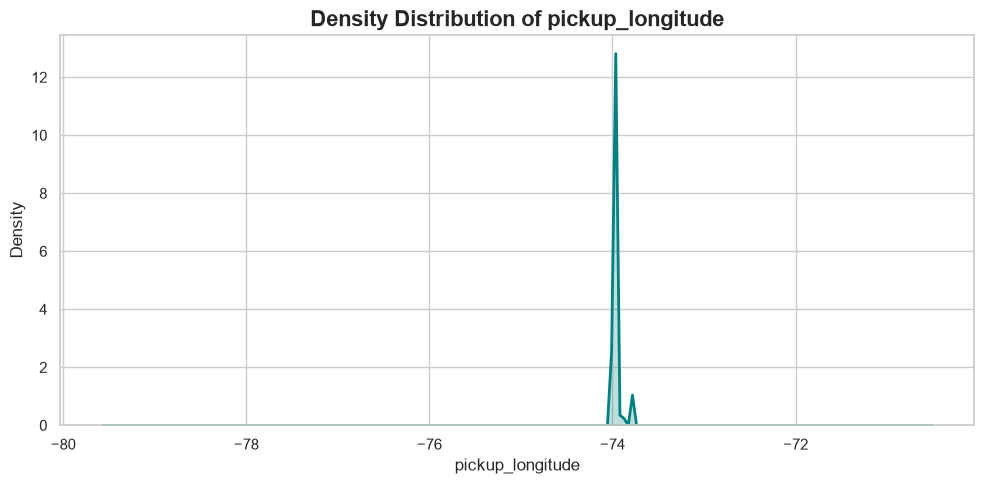

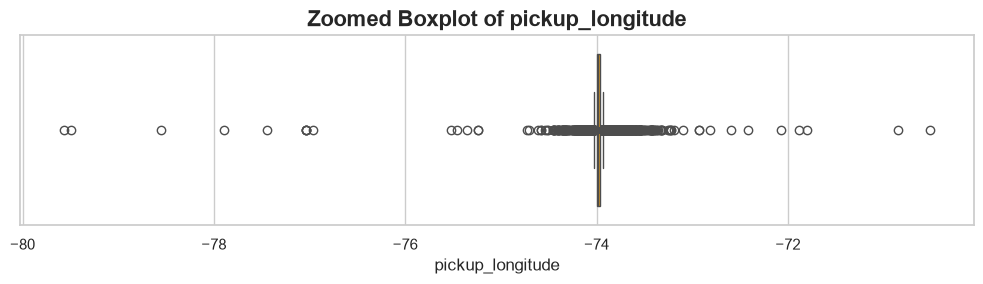

--------------------------------------------------------------------------------


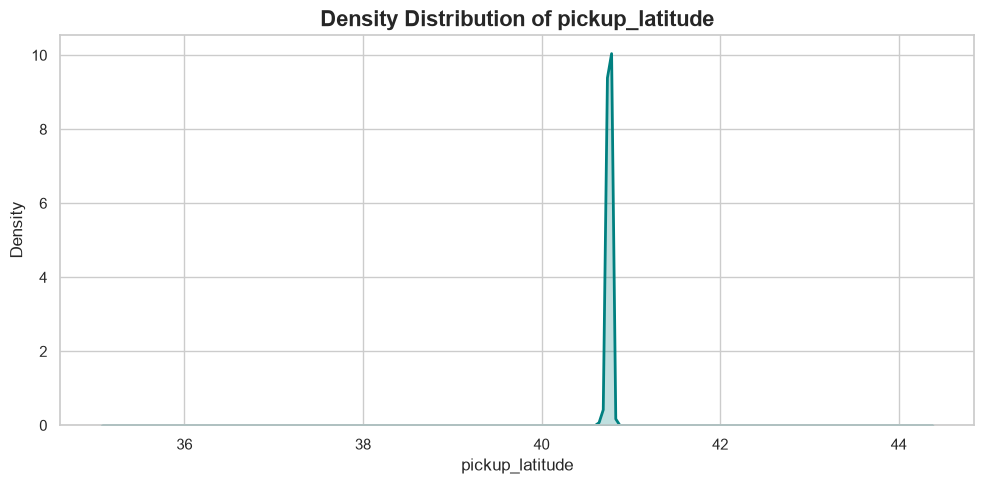

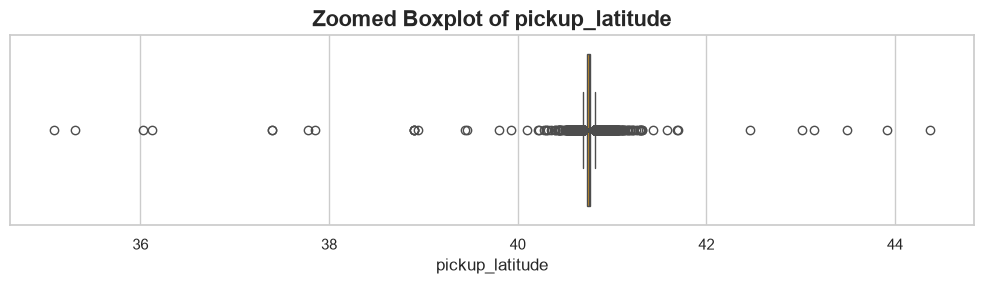

--------------------------------------------------------------------------------


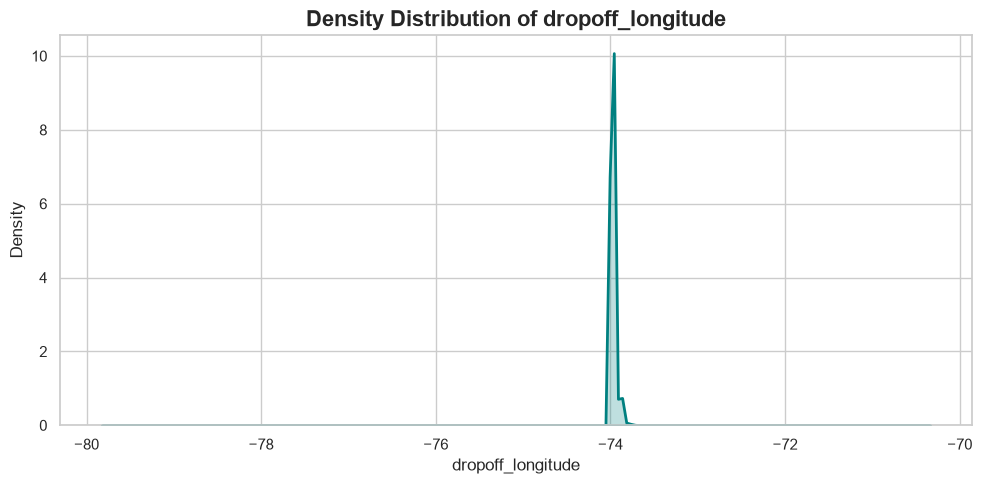

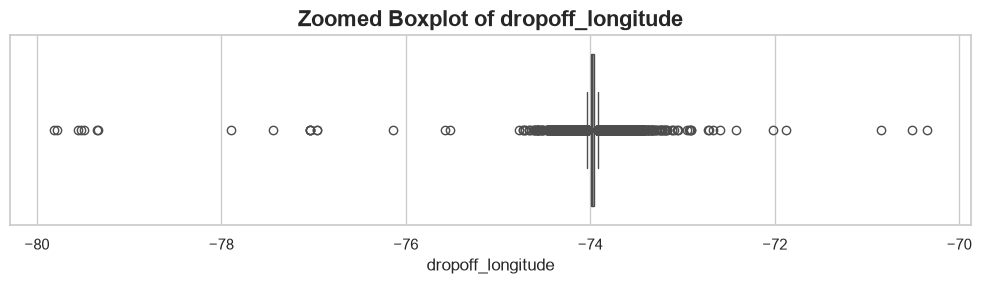

--------------------------------------------------------------------------------


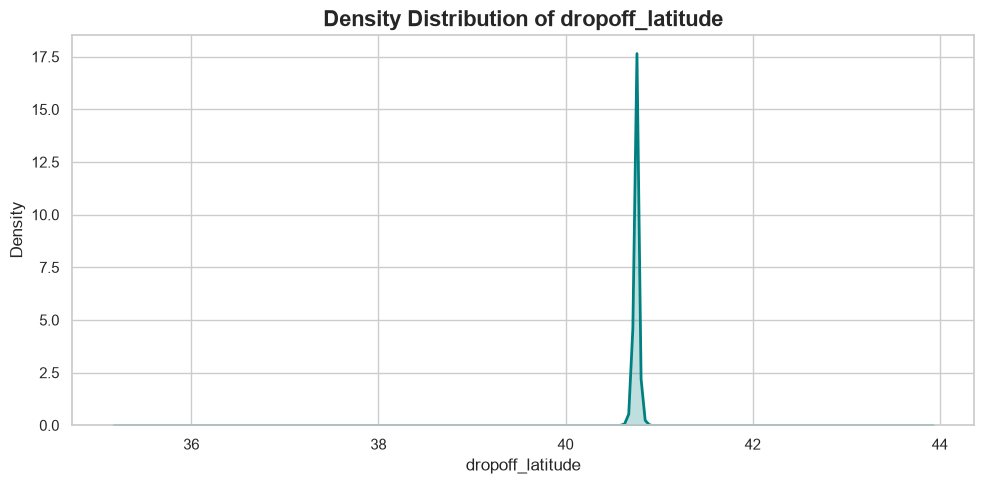

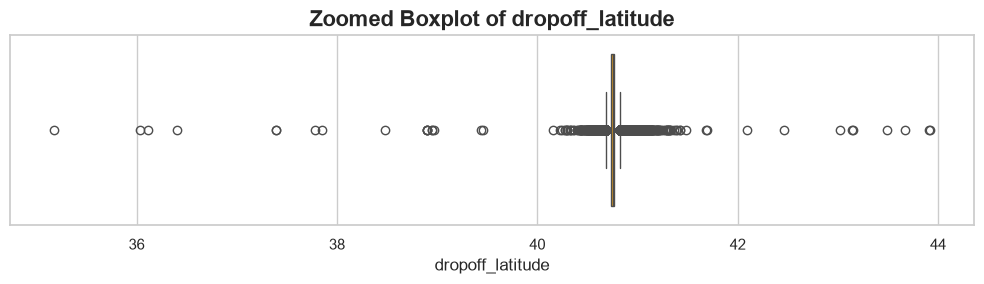

--------------------------------------------------------------------------------


In [63]:
# Define the continuous numerical columns to analyze
continuous_cols = [
    'trip_duration', 
    'pickup_longitude', 'pickup_latitude', 
    'dropoff_longitude', 'dropoff_latitude'
]

sns.set_theme(style="whitegrid")

# Loop through each column and generate standalone, large figures
for col in continuous_cols:
    # Filter out extreme outliers just for plotting clarity
    if 'duration' in col:
        plot_data = df_train[df_train[col] < 7200][col]
    else:
        plot_data = df_train[df_train[col].between(-80, -70) | df_train[col].between(35, 45)][col]

    # --- 1. Density Distribution Plot (Standalone & Large) ---
    plt.figure(figsize=(10, 5))
    sns.kdeplot(plot_data, color='teal', fill=True, linewidth=2)
    plt.title(f'Density Distribution of {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- 2. Boxplot (Standalone & Large) ---
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=plot_data, color='orange')
    plt.title(f'Zoomed Boxplot of {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("-" * 80) # Adds a clean visual separator between variables in your notebook

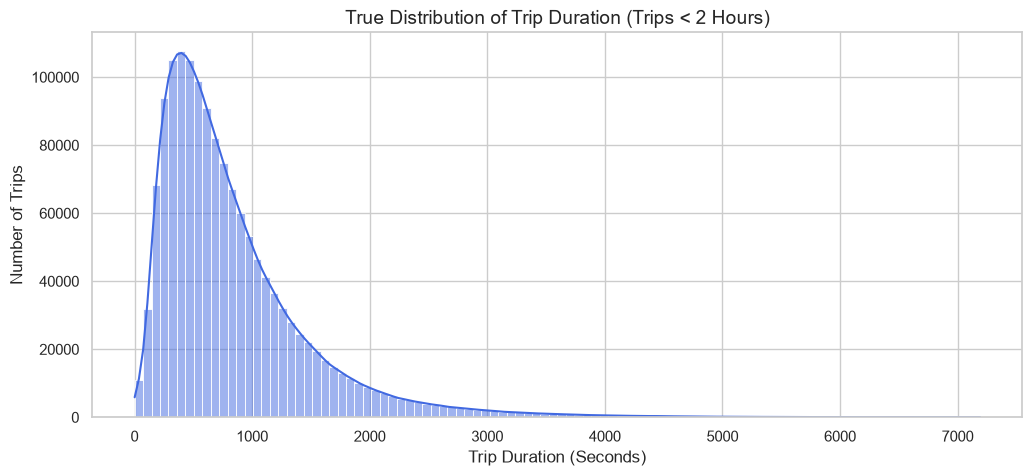

In [64]:
# Create a temporary filtered dataframe for visualization purposes
nyc_bounds = {
    'min_long': -74.5, 'max_long': -73.5,
    'min_lat': 40.5, 'max_lat': 41.0
}

# Filter out the extreme errors
df_viz = df_train[
    (df_train['trip_duration'] < 7200) &  # Trips under 2 hours
    (df_train['pickup_longitude'] > nyc_bounds['min_long']) & 
    (df_train['pickup_longitude'] < nyc_bounds['max_long']) &
    (df_train['pickup_latitude'] > nyc_bounds['min_lat']) & 
    (df_train['pickup_latitude'] < nyc_bounds['max_lat'])
]

# Plot the filtered trip duration to see the true distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_viz['trip_duration'], bins=100, color='royalblue',kde=True)
plt.title('True Distribution of Trip Duration (Trips < 2 Hours)', fontsize=14)
plt.xlabel('Trip Duration (Seconds)')
plt.ylabel('Number of Trips')
plt.show()

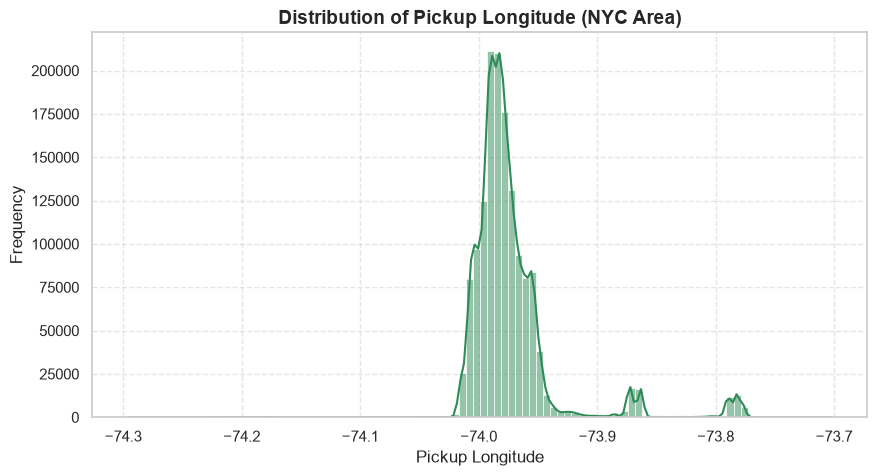

In [65]:
# Filter longitudes strictly around New York City bounds
valid_pickup_lon = df_train['pickup_longitude'][
    (df_train['pickup_longitude'] > -74.3) & (df_train['pickup_longitude'] < -73.7)
]

plt.figure(figsize=(10, 5))
sns.histplot(valid_pickup_lon, bins=100, kde=True, color='seagreen')
plt.title('Distribution of Pickup Longitude (NYC Area)', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Longitude', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

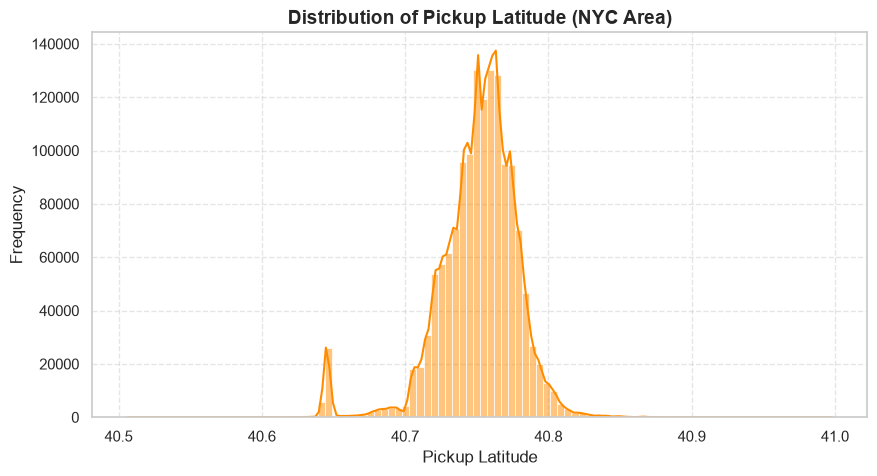

In [66]:
# Filter latitudes strictly around New York City bounds
valid_pickup_lat = df_train['pickup_latitude'][
    (df_train['pickup_latitude'] > 40.5) & (df_train['pickup_latitude'] < 41.0)
]

plt.figure(figsize=(10, 5))
sns.histplot(valid_pickup_lat, bins=100, kde=True, color='darkorange')
plt.title('Distribution of Pickup Latitude (NYC Area)', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Latitude', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Univariate analysis for categorical variables

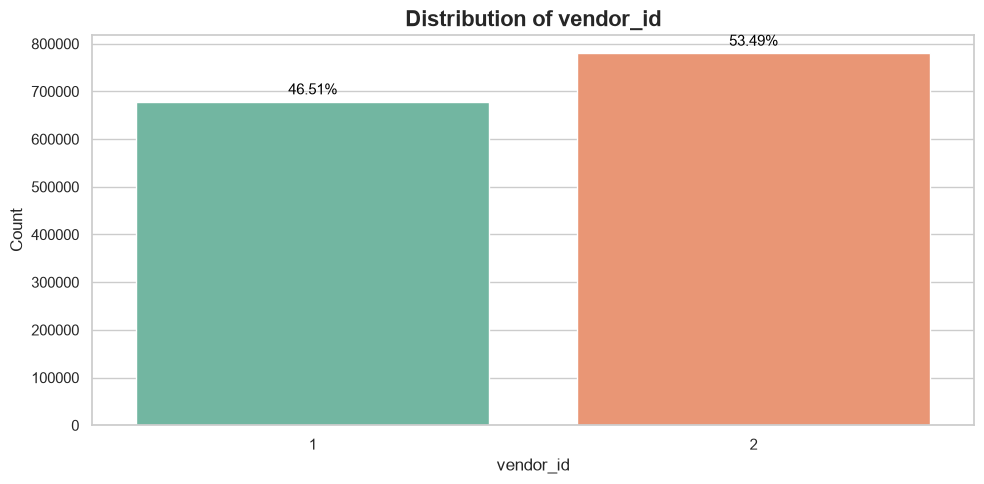

--------------------------------------------------------------------------------


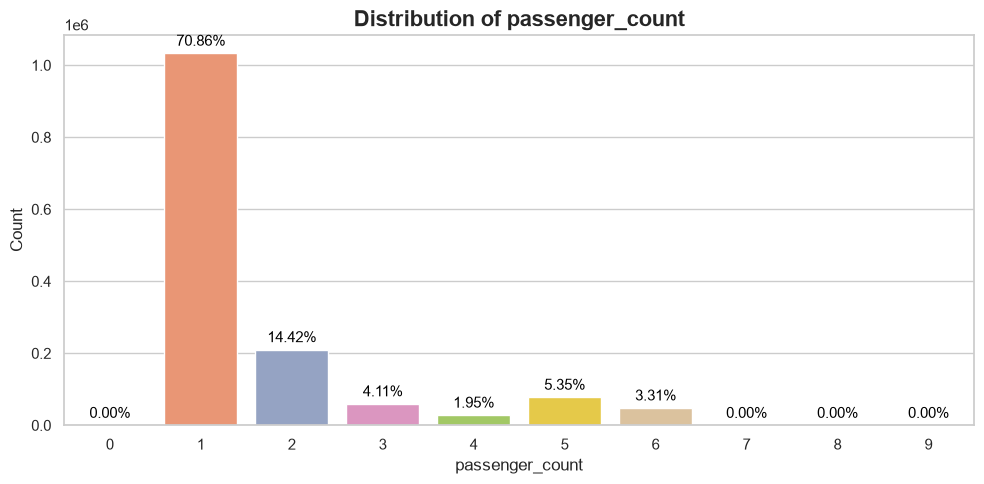

--------------------------------------------------------------------------------


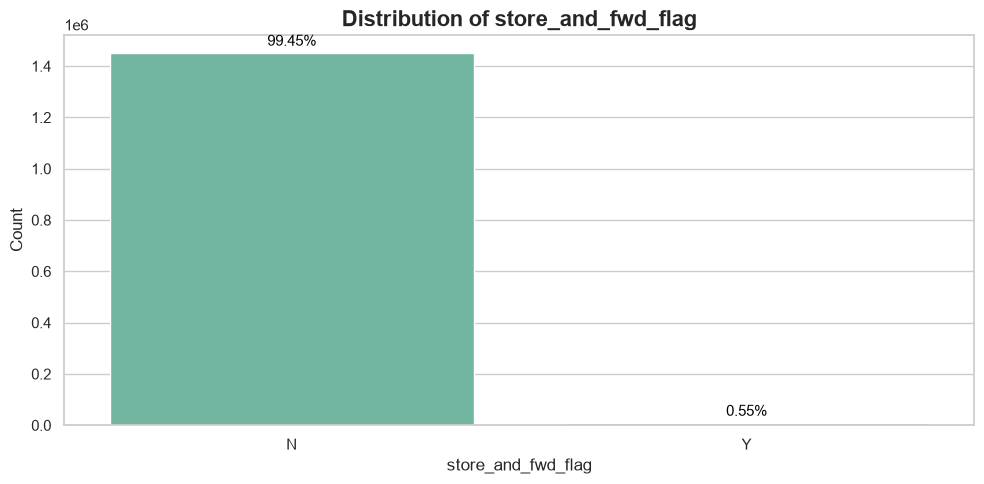

--------------------------------------------------------------------------------


In [67]:
# Define your categorical columns (including passenger_count and vendor_id since they represent discrete classes)
categorical_cols = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']

sns.set_theme(style="whitegrid")

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Create the count plot
    ax = sns.countplot(data=df_train, x=col, palette='Set2')
    
    plt.title(f'Distribution of {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # Add percentage annotations above each bar for better insight
    total = len(df_train)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Avoid division by zero or empty bars
            percentage = f'{(height / total) * 100:.2f}%'
            ax.annotate(
                percentage, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=11, color='black', 
                xytext=(0, 3), textcoords='offset points'
            )
            
    plt.tight_layout()
    plt.show()
    print("-" * 80)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">8. Bivariate Analysis with Visualisation</p>

### Correlation heatmap

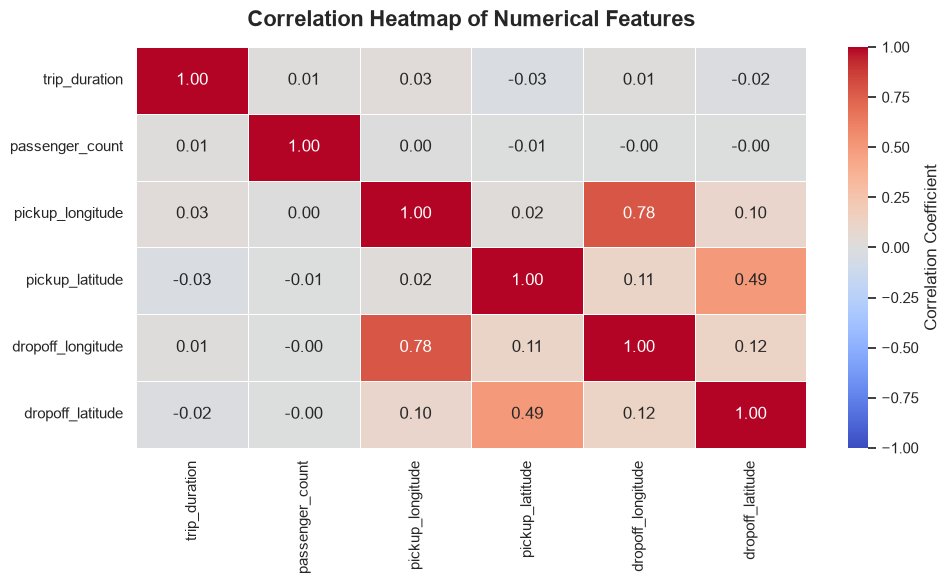

In [69]:
# 1. Select only numerical columns (including trip_duration)
numerical_cols_for_corr = [
    'trip_duration', 
    'passenger_count', 
    'pickup_longitude', 'pickup_latitude', 
    'dropoff_longitude', 'dropoff_latitude'
]

# 2. Calculate the correlation matrix
corr_matrix = df_train[numerical_cols_for_corr].corr()

# 3. Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,         # Show the correlation coefficient numbers inside the cells
    fmt=".2f",          # Format numbers to 2 decimal places
    cmap='coolwarm',    # Color map (blue for negative, red for positive)
    vmin=-1, vmax=1,    # Set fixed scale from -1 to 1
    linewidths=0.5,     # Add grid lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Pairplot

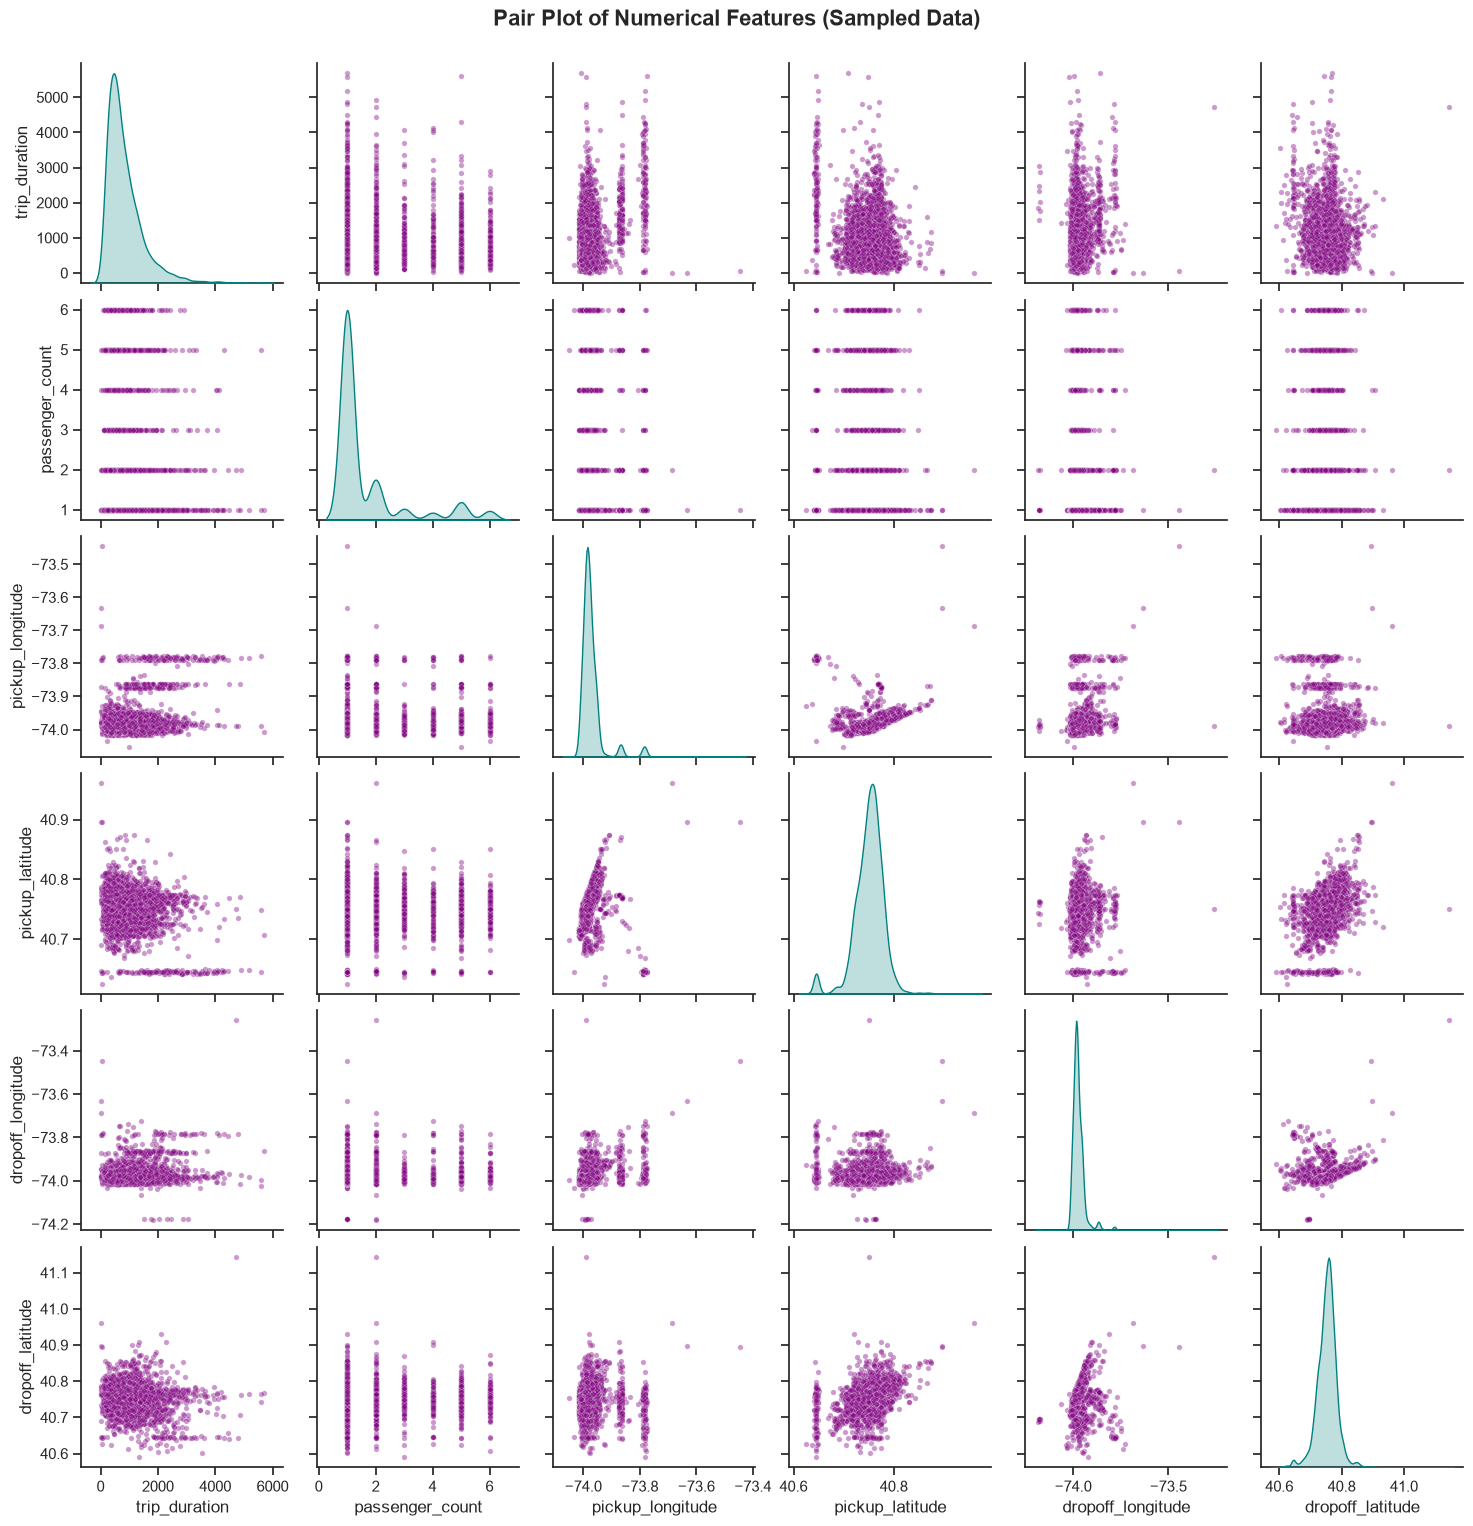

In [70]:
# Define the numerical columns you want to include in the pair plot
numerical_cols_for_pairplot = [
    'trip_duration', 
    'passenger_count', 
    'pickup_longitude', 'pickup_latitude', 
    'dropoff_longitude', 'dropoff_latitude'
]

# Take a random sample of 5,000 rows to ensure fast rendering and prevent memory crashes
df_sample = df_train[numerical_cols_for_pairplot].sample(n=5000, random_state=42)

# Filter out extreme duration or coordinate outliers in the sample for a clean plot
df_sample = df_sample[
    (df_sample['trip_duration'] < 7200) & 
    (df_sample['pickup_longitude'].between(-80, -70)) & 
    (df_sample['pickup_latitude'].between(35, 45))
]

# Set the visual theme
sns.set_theme(style="ticks")

# Generate the pair plot
# diag_kind='kde' creates a smooth density curve on the diagonal instead of a histogram
g = sns.pairplot(
    df_sample, 
    diag_kind='kde', 
    plot_kws={'alpha': 0.4, 's': 15, 'color': 'purple'},
    diag_kws={'color': 'teal'}
)

# Add an overall title
g.fig.suptitle('Pair Plot of Numerical Features (Sampled Data)', y=1.02, fontsize=16, fontweight='bold')

plt.show()

## Categorical Features vs Target Feature Price Boxplot

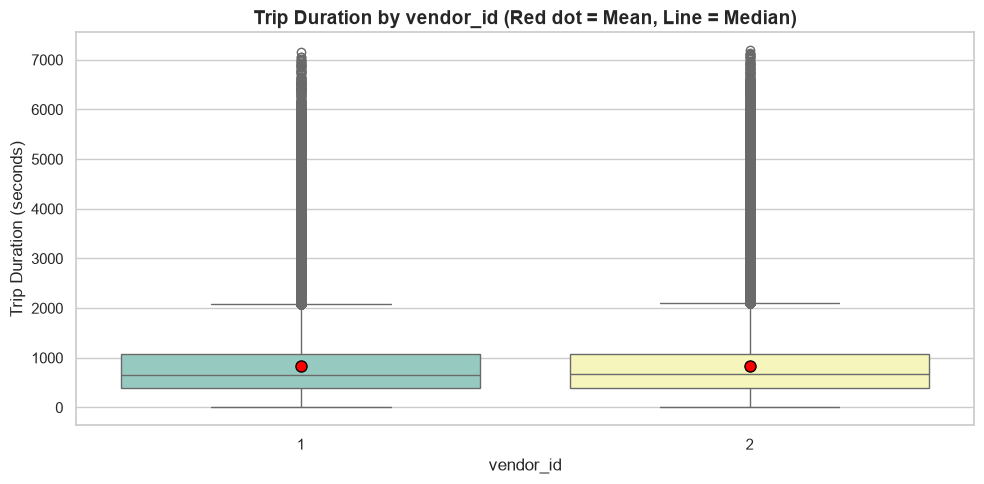

--------------------------------------------------------------------------------


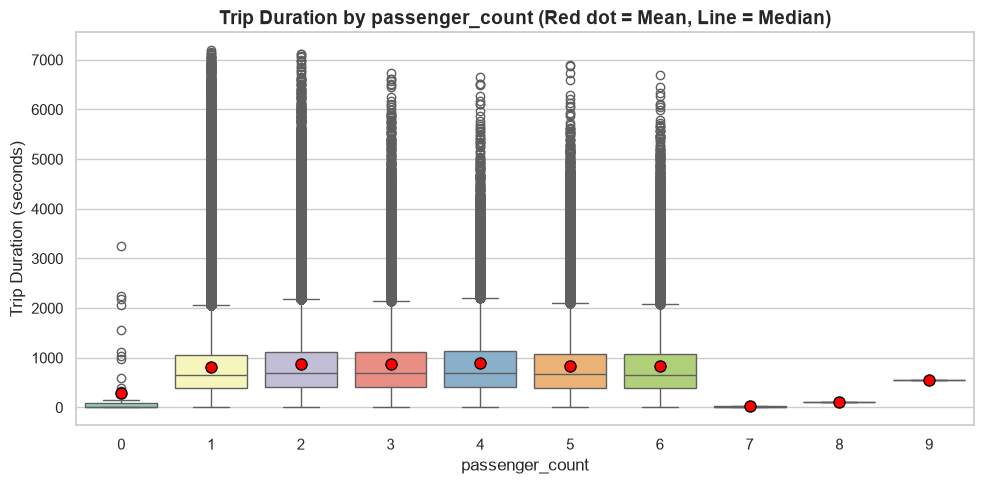

--------------------------------------------------------------------------------


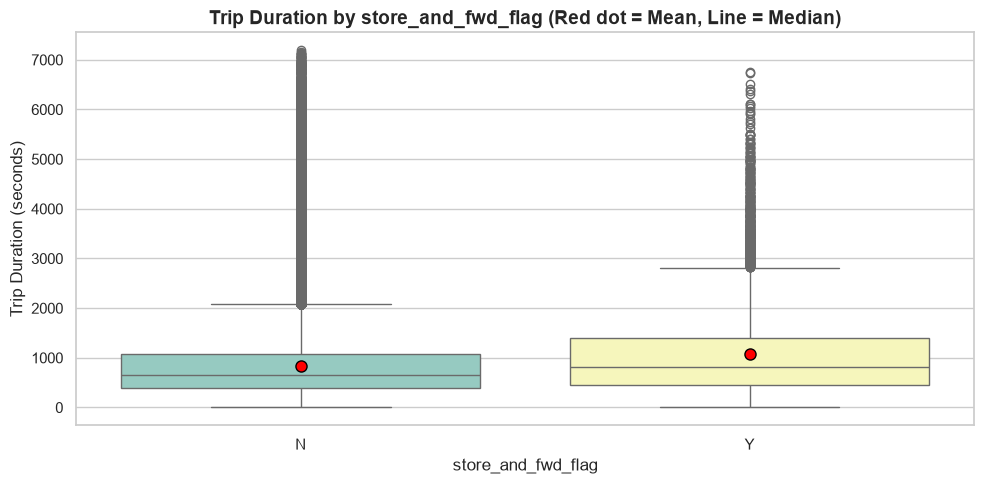

--------------------------------------------------------------------------------


In [72]:
# Define categorical features to compare against the target
categorical_cols = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']

sns.set_theme(style="whitegrid")

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Filter out extreme trip duration outliers for a clean, readable plot (e.g., trips under 2 hours)
    plot_df = df_train[df_train['trip_duration'] < 7200]
    
    # Create the boxplot
    sns.boxplot(
        data=plot_df, 
        x=col, 
        y='trip_duration', 
        palette='Set3',
        showmeans=True, # Shows a small marker for the mean alongside the median line
        meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"}
    )
    
    plt.title(f'Trip Duration by {col} (Red dot = Mean, Line = Median)', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Trip Duration (seconds)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    print("-" * 80)

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">9. Mutual Information Scores</p>

### Seperating X and Y

In [73]:
X = df_train.drop(labels=['trip_duration'],axis=1)
y = df_train[['trip_duration']]

### Calculating Mutual Information scores for regression

In [ ]:
# Define your feature matrix (X) and target variable (y)
# We drop non-numeric columns like datetimes and IDs
features = [
    'vendor_id', 'passenger_count', 
    'pickup_longitude', 'pickup_latitude', 
    'dropoff_longitude', 'dropoff_latitude'
]

X = df_train[features]
y = df_train['trip_duration']

# Optional: Since the dataset is huge (1.4M rows), take a sample of 50,000 rows 
# to calculate MI scores instantly without freezing your notebook
sample_idx = X.sample(n=50000, random_state=42).index
X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]

# Calculate mutual information scores
mi_scores = mutual_info_regression(X_sample, y_sample, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# Display the scores table
display(mi_scores.to_frame())

,MI Scores
pickup_longitude,0.079912
dropoff_latitude,0.071289
pickup_latitude,0.066635
dropoff_longitude,0.055886
vendor_id,0.001791
passenger_count,0.000000


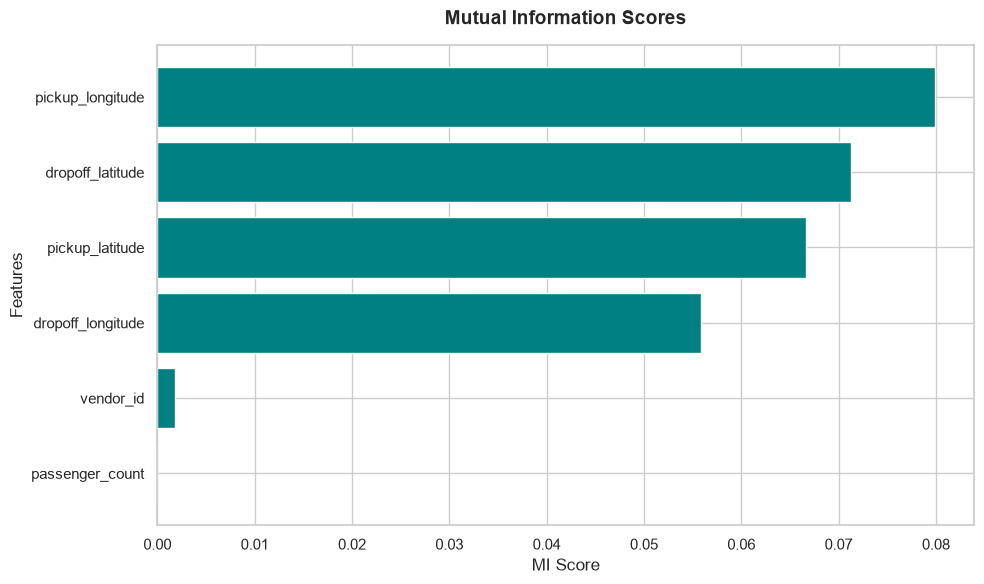

In [76]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    
    plt.figure(figsize=(10, 6))
    plt.barh(width, scores, color='teal')
    plt.yticks(width, ticks, fontsize=11)
    plt.title("Mutual Information Scores", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("MI Score", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_mi_scores(mi_scores)

## Conclusion :
The Mutual Information analysis indicates that the spatial coordinates (`pickup_longitude`, `dropoff_longitude`, `pickup_latitude`, and `dropoff_latitude`) share the strongest non-linear dependence with `trip_duration`. This makes logical sense, as geographical start and end points heavily dictate the distance and traffic conditions of a route in New York City.